## Deprecated SDK imports removed

This project no longer depends on `bigdata-client` or `bigdata-research-tools`. See **MIGRATION_NOTES.md** / **README.md** and [Thematic_Screener_CLI](../Thematic_Screener_CLI/) for the REST + `bigdata-smart-batching` + OpenAI pattern. Pass company CSVs (`RP_ENTITY_ID`, `COMPANY_NAME`) instead of watchlists.


 # Crypto Adoption Analysis


Identify cryptocurrencies positioned to benefit from institutional adoption ahead of broader market recognition. This workflow adapts our proven equity research screening methodology to digital assets, systematically identifying cryptocurrencies genuinely aligned with key institutional adoption drivers.
​


 ## Why It Matters

Crypto institutional adoption is accelerating rapidly, but identifying which digital assets stand to benefit most requires analyzing vast amounts of information from news, regulatory updates, and market data. Manual analysis is inefficient and prone to bias. As institutional capital enters the market, the window to identify well-positioned cryptocurrencies before mass recognition is narrowing. A systematic, data-driven approach is essential to uncover emerging leaders ahead of the crowd.

 ## What It Does



The ThematicScreener class delivers institutional-grade thematic intelligence at scale. Designed for analysts, PMs, and strategists managing thematic portfolios or scouting new ideas, it systematically connects different assets to investment themes using unstructured data from news, earnings calls, and filings.
​



 ## How It Works



 ThematicScreener follows a systematic 4-step workflow to transform investment themes into actionable intelligence:
- Mindmap Theme Taxonomy - LLM-powered breakdown of investment themes into specific, measurable sub-categories using automated theme tree generation
- Search with Premium Sources - Semantic content retrieval leveraging our dedicated Crypto Wire source, delivering ‘gold-standard’ quality, topicality, volume, source diversity, coverage and timeliness for comprehensive digital asset intelligence
- Label Results - LLM-based classification to analyze text chunks and determine relevance to sub-themes, filtering out content not explicitly linked to the main theme
- Post-process & Score - Qualitative-to-quantitative transformation that aggregates thematic signals into structured scoring methodologies for portfolio-level assessment



 ## A Real-World Use Case



This cookbook demonstrates a systematic approach for identifying institutional adoption trends across 15 major cryptocurrencies, leveraging our dedicated Crypto Wire source. The workflow enables early detection of digital assets positioned to benefit from increasing institutional capital flows, delivering actionable insights before these trends become widely apparent.


 ## Async Compatibility Setup



 **Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:



 ### Why is this needed?



 Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:



 ```

 RuntimeError: asyncio.run() cannot be called from a running event loop

 ```



 The `nest_asyncio.apply()` command patches this to allow nested event loops.



 💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")


✅ nest_asyncio applied


 ## Environment Setup



 The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")


✅ Local environment setup complete


 ## Load Credentials

In [3]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_API_KEY, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")


✅ Credentials loaded from .env file


 ## Import Required Libraries

In [4]:
import json
import pandas as pd
from openai import OpenAI

from src.bigdata_rest import BigdataRestClient
from src.openai_utils import sampling_params_for_model
from src.search_entities import search_by_entities, post_process_dataframe

# REST client (X-API-KEY auth) + OpenAI client replace bigdata-client / bigdata-research-tools
rest_client = BigdataRestClient(api_key=BIGDATA_API_KEY)
openai_client = OpenAI(api_key=OPENAI_API_KEY)
print("✅ REST + OpenAI clients ready")


✅ REST + OpenAI clients ready


 ## Optional: Plotly Display Configuration



 For better visualization rendering, you can also set the Plotly renderer:

In [5]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")


✅ Plotly configured for Jupyter/VS Code


 ## Define Output Paths



 We define the output paths for our thematic screening results.

In [6]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/thematic_screener_results.xlsx"


 ## Connecting to Bigdata



 We authenticate directly against the Bigdata.com REST API (`X-API-KEY` header) instead of the deprecated SDK client. The `rest_client` / `openai_client` objects were created above.


In [7]:
# rest_client / openai_client were already created in the imports cell above.
print(f"✅ Connected to {rest_client.base_url}")


✅ Connected to https://api.bigdata.com


 ## Defining your Screening Parameters



 -  **Main Theme** (``main_theme``): The central concept to explore

 -  **Entity Universe** (``entity_ids`` / ``entity_names``): The set of entities to screen. No SDK watchlists are available anymore — entity IDs are resolved once via ``BigdataRestClient().find_companies(name)`` and then hardcoded here as a small, verified list (cost control: 2-3 entities).

 -  **Time Period** (``start_date`` and ``end_date``): The date range over which to run the search. Kept to a narrow ~30 day window for cost control.

 -  **Document Limit** (``document_limit``): The maximum number of documents to return per entity/theme query to the Bigdata API.

 -  **Model Selection** (``llm_model``): The OpenAI model used to generate the theme taxonomy and label the search result chunks.


In [8]:
# ===== Theme Definition =====
main_theme = "Crypto Institutional Adoption"
focus = "Include know your customer (KYC) and anti-money laundering (AML) themes"

# ===== Entity Universe =====
# Pre-migration used Top-15 crypto watchlist. REST uses crypto-exposed public cos.
entity_ids = ['D69946', 'C72B8F', '56AAC4', 'E09E2B', 'D8442A', '228D42', '0157B1', '4A6F00', 'DD3BB1', '12E454']
entity_names = {'D69946': 'Coinbase Global Inc.', 'C72B8F': 'Strategy Inc. (MicroStrategy)', '56AAC4': 'Riot Platforms Inc.', 'E09E2B': 'NVIDIA Corp.', 'D8442A': 'Apple Inc.', '228D42': 'Microsoft Corp.', '0157B1': 'Amazon.com Inc.', '4A6F00': 'Alphabet Inc.', 'DD3BB1': 'Tesla Inc.', '12E454': 'Meta Platforms Inc.'}

# ===== LLM Specification =====
llm_model = "gpt-5.6-luna"

# ===== Specify Time Range (restored pre-migration window) =====
start_date = "2025-01-01"
end_date = "2025-09-08"


 ## Mindmap a Theme Taxonomy with OpenAI



 `bigdata-research-tools`' `generate_theme_tree` is no longer available. We replicate the same idea with a direct OpenAI call: break the main theme down into a handful of specific, measurable sub-themes expressed as descriptive sentences.


In [9]:
def generate_themes(main_theme: str, focus: str = "", n_themes: int = 5) -> list[str]:
    """Generate a small theme taxonomy using OpenAI (replaces bigdata_research_tools.generate_theme_tree)."""
    prompt = f'''Generate {n_themes} specific, measurable sub-themes for analyzing: "{main_theme}"

{"Focus: " + focus if focus else ""}

Each sub-theme should be a short descriptive sentence that explicitly connects back to the main theme.
Return ONLY a JSON array of strings, e.g.:
["Sub-theme sentence 1", "Sub-theme sentence 2"]
'''
    response = openai_client.chat.completions.create(
        model=llm_model,
        messages=[{"role": "user", "content": prompt}],
        **sampling_params_for_model(llm_model, temperature=0.3),
    )
    text = response.choices[0].message.content.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]
        text = text.strip()
    return json.loads(text)


node_summaries = generate_themes(main_theme, focus=focus, n_themes=5)
for sentence in node_summaries:
    print("-", sentence)


- Measure crypto institutional adoption by tracking the percentage of banks, asset managers, and payment firms offering cryptocurrency products or services.
- Assess crypto institutional adoption through the number and value of institutional digital-asset transactions processed monthly.
- Evaluate how KYC requirements influence crypto institutional adoption by measuring onboarding completion rates, verification times, and customer drop-off rates.
- Measure the impact of AML controls on crypto institutional adoption by tracking suspicious-activity detection rates, compliance costs, and regulatory enforcement incidents.
- Compare crypto institutional adoption across jurisdictions by analyzing licensed institutional participants, approved products, and KYC/AML compliance requirements.


 Each generated sentence explicitly connects a sub-theme back to the main theme, so both the search step and the labeling step stay contextually anchored to "Crypto Institutional Adoption".


In [10]:
# In this simplified REST pipeline the same sentences double as search queries
# and as the label taxonomy handed to the OpenAI labeler below.
labels = node_summaries


 ## Retrieve Content using Bigdata’s Search Capabilities



 With the theme taxonomy and screening parameters defined, we call `search_by_entities` (`src/search_entities.py`), which issues one `/v1/search` REST call per entity/theme-sentence combination and returns a chunk-level DataFrame.

 -  **Document Limit** (``document_limit``): The maximum number of documents to return per query to the Bigdata API. Kept small for cost control.


In [11]:
# Cost control: small per-query document cap
document_limit = 10


In [12]:
df_sentences = search_by_entities(
    entity_ids=entity_ids,
    entity_names=entity_names,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    rest_client=rest_client,
    document_limit=document_limit,
)

print(f"Retrieved {len(df_sentences)} chunk-level rows")
df_sentences.head()


Searching entities:   0%|          | 0/10 [00:00<?, ?it/s]

Searching entities:  10%|█         | 1/10 [00:08<01:16,  8.54s/it]

Searching entities:  20%|██        | 2/10 [00:13<00:50,  6.36s/it]

Searching entities:  30%|███       | 3/10 [00:18<00:41,  5.97s/it]

Searching entities:  40%|████      | 4/10 [00:22<00:31,  5.24s/it]

...

Searching entities:  90%|█████████ | 9/10 [00:46<00:04,  4.76s/it]

Searching entities: 100%|██████████| 10/10 [00:50<00:00,  4.66s/it]

Searching entities: 100%|██████████| 10/10 [00:50<00:00,  5.05s/it]

Retrieved 47 chunk-level rows


,timestamp_utc,document_id,sentence_id,headline,entity_id,entity_name,text
0,2025-01-17 19:21:46,8C026DFF0D2593D724830EBA4B30F67D,8C026DFF0D2593D724830EBA4B30F67D-0,"2025 To See Dogecoin ETF, Strategic Bitcoin Re...",C72B8F,Strategy Inc. (MicroStrategy),The firm also expects normalization of skew as...
1,2025-01-24 23:58:45,8D975BD290E4964CCF4843170D28ED2B,8D975BD290E4964CCF4843170D28ED2B-0,Why Should You Start Accepting Crypto Payments?,228D42,Microsoft Corp.,"This whole journey has really paid off, as cry..."
2,2025-02-13 01:44:41,090D2C0AD330AA290C1AB43F4C7A3CD4,090D2C0AD330AA290C1AB43F4C7A3CD4-0,"“Bitcoin Is On Pace To Likely Reach Our $1,500...",DD3BB1,Tesla Inc.,The value on corporate balance sheets quintrup...
3,2025-03-18 09:02:01,D908010F86A2E6171C1EA9BDDA8BD104,D908010F86A2E6171C1EA9BDDA8BD104-0,HTX Ventures: Striking a Balance between Compl...,D69946,Coinbase Global Inc.,"SINGAPORE, March 18, 2025 /PRNewswire/ -- HTX,..."
4,2025-03-19 02:28:28,66534185CF9A63F522A5A7F774680D97,66534185CF9A63F522A5A7F774680D97-0,"BIG CRYPTO NEWS! SEC PAUL ATKINS CONFIRMATION,...",228D42,Microsoft Corp.,Crypto News: SEC Chair Paul Atkins confirmatio...


 ## Label the Results



 `bigdata_research_tools.labeler.ScreenerLabeler` is no longer available. We replicate its behavior with a direct OpenAI call per text chunk, asking the model to pick the closest matching sub-theme (or `"unclear"` if none apply). Chunks labeled `"unclear"` are filtered out by `post_process_dataframe`.

 Cost control: only a small sample of retrieved chunks is sent to OpenAI for labeling.


In [13]:
def label_crypto_text(text: str, entity_name: str, themes: list[str]) -> dict:
    """Classify a text chunk against the theme taxonomy using OpenAI (replaces ScreenerLabeler)."""
    prompt = f'''Analyze this text about {entity_name} and identify which theme it relates to most.

Themes: {", ".join(themes)}

Text: {text}

Return JSON: {{"label": "the closest matching theme, verbatim, or \'unclear\'", "motivation": "brief one-sentence explanation"}}
'''
    response = openai_client.chat.completions.create(
        model=llm_model,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        **sampling_params_for_model(llm_model, temperature=0.0),
    )
    return json.loads(response.choices[0].message.content)


# Label full retrieved set
MAX_ROWS_TO_LABEL = 10_000
if len(df_sentences) > MAX_ROWS_TO_LABEL:
    df_sentences = df_sentences.head(MAX_ROWS_TO_LABEL).reset_index(drop=True)

if not df_sentences.empty:
    label_results = df_sentences.apply(
        lambda row: label_crypto_text(row["text"], row["entity_name"], node_summaries),
        axis=1,
    )
    df_sentences["label"] = label_results.apply(lambda x: x.get("label", "unclear"))
    df_sentences["motivation"] = label_results.apply(lambda x: x.get("motivation", ""))
else:
    df_sentences["label"] = pd.Series(dtype=str)
    df_sentences["motivation"] = pd.Series(dtype=str)

print(f"Labeled {len(df_sentences)} rows")
df_sentences.head()


Labeled 47 rows


,timestamp_utc,document_id,sentence_id,headline,entity_id,entity_name,text,label,motivation
0,2025-01-17 19:21:46,8C026DFF0D2593D724830EBA4B30F67D,8C026DFF0D2593D724830EBA4B30F67D-0,"2025 To See Dogecoin ETF, Strategic Bitcoin Re...",C72B8F,Strategy Inc. (MicroStrategy),The firm also expects normalization of skew as...,Measure crypto institutional adoption by track...,The text focuses on growing institutional part...
1,2025-01-24 23:58:45,8D975BD290E4964CCF4843170D28ED2B,8D975BD290E4964CCF4843170D28ED2B-0,Why Should You Start Accepting Crypto Payments?,228D42,Microsoft Corp.,"This whole journey has really paid off, as cry...",Measure crypto institutional adoption by track...,The text cites the share of companies acceptin...
2,2025-02-13 01:44:41,090D2C0AD330AA290C1AB43F4C7A3CD4,090D2C0AD330AA290C1AB43F4C7A3CD4-0,"“Bitcoin Is On Pace To Likely Reach Our $1,500...",DD3BB1,Tesla Inc.,The value on corporate balance sheets quintrup...,Measure crypto institutional adoption by track...,The text highlights growing corporate Bitcoin ...
3,2025-03-18 09:02:01,D908010F86A2E6171C1EA9BDDA8BD104,D908010F86A2E6171C1EA9BDDA8BD104-0,HTX Ventures: Striking a Balance between Compl...,D69946,Coinbase Global Inc.,"SINGAPORE, March 18, 2025 /PRNewswire/ -- HTX,...",Compare crypto institutional adoption across j...,The text focuses on MiCAR’s unified regulatory...
4,2025-03-19 02:28:28,66534185CF9A63F522A5A7F774680D97,66534185CF9A63F522A5A7F774680D97-0,"BIG CRYPTO NEWS! SEC PAUL ATKINS CONFIRMATION,...",228D42,Microsoft Corp.,Crypto News: SEC Chair Paul Atkins confirmatio...,Measure crypto institutional adoption by track...,The text cites Coinbase data showing that over...


In [14]:
# No merge needed: labeling above wrote "label"/"motivation" directly onto df_sentences
df = df_sentences.copy()


In [15]:
df = post_process_dataframe(df)

 ## Assess Thematic Exposure Across Your Entities

 We’ll look at the most exposed companies to our main theme. `score_entities` (defined below) replaces `bigdata_research_tools.workflows.utils.get_scored_df`: it counts, per entity, how many labeled chunks fall under each sub-theme, then sums them into a composite thematic score (`df_entity`).


In [16]:
def score_entities(df: pd.DataFrame, themes: list[str]) -> pd.DataFrame:
    """Aggregate thematic signal counts per entity (replaces bigdata_research_tools.get_scored_df)."""
    rows = []
    for entity in df["Entity"].unique():
        entity_df = df[df["Entity"] == entity]
        theme_counts = {theme: int((entity_df["Theme"] == theme).sum()) for theme in themes}
        row = {
            "Entity": entity,
            "Total Mentions": len(entity_df),
            "Themes Covered": sum(1 for count in theme_counts.values() if count > 0),
            **theme_counts,
            "Composite Score": sum(theme_counts.values()),
        }
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values("Composite Score", ascending=False)
        .reset_index(drop=True)
    )


df_entity = score_entities(df, node_summaries) if not df.empty else pd.DataFrame()
df_entity


,Entity,Total Mentions,Themes Covered,"Measure crypto institutional adoption by tracking the percentage of banks, asset managers, and payment firms offering cryptocurrency products or services.",Assess crypto institutional adoption through the number and value of institutional digital-asset transactions processed monthly.,"Evaluate how KYC requirements influence crypto institutional adoption by measuring onboarding completion rates, verification times, and customer drop-off rates.","Measure the impact of AML controls on crypto institutional adoption by tracking suspicious-activity detection rates, compliance costs, and regulatory enforcement incidents.","Compare crypto institutional adoption across jurisdictions by analyzing licensed institutional participants, approved products, and KYC/AML compliance requirements.",Composite Score
0,Coinbase Global Inc.,16,4,11,0,2,1,2,16
1,Strategy Inc. (MicroStrategy),10,1,10,0,0,0,0,10
2,Alphabet Inc.,5,3,3,0,1,1,0,5
3,Riot Platforms Inc.,4,3,2,0,0,1,1,4
4,Apple Inc.,3,3,1,0,1,1,0,3
5,Microsoft Corp.,3,1,3,0,0,0,0,3
6,Meta Platforms Inc.,2,1,2,0,0,0,0,2
7,Tesla Inc.,2,2,1,0,0,0,1,2
8,Amazon.com Inc.,1,1,1,0,0,0,0,1


In [17]:
from src.visualization_tool import display_figures

/Users/franciscogomez/git/bigdata/wt-html-refresh/Screener_for_Crypto/src/visualization_tool.py:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


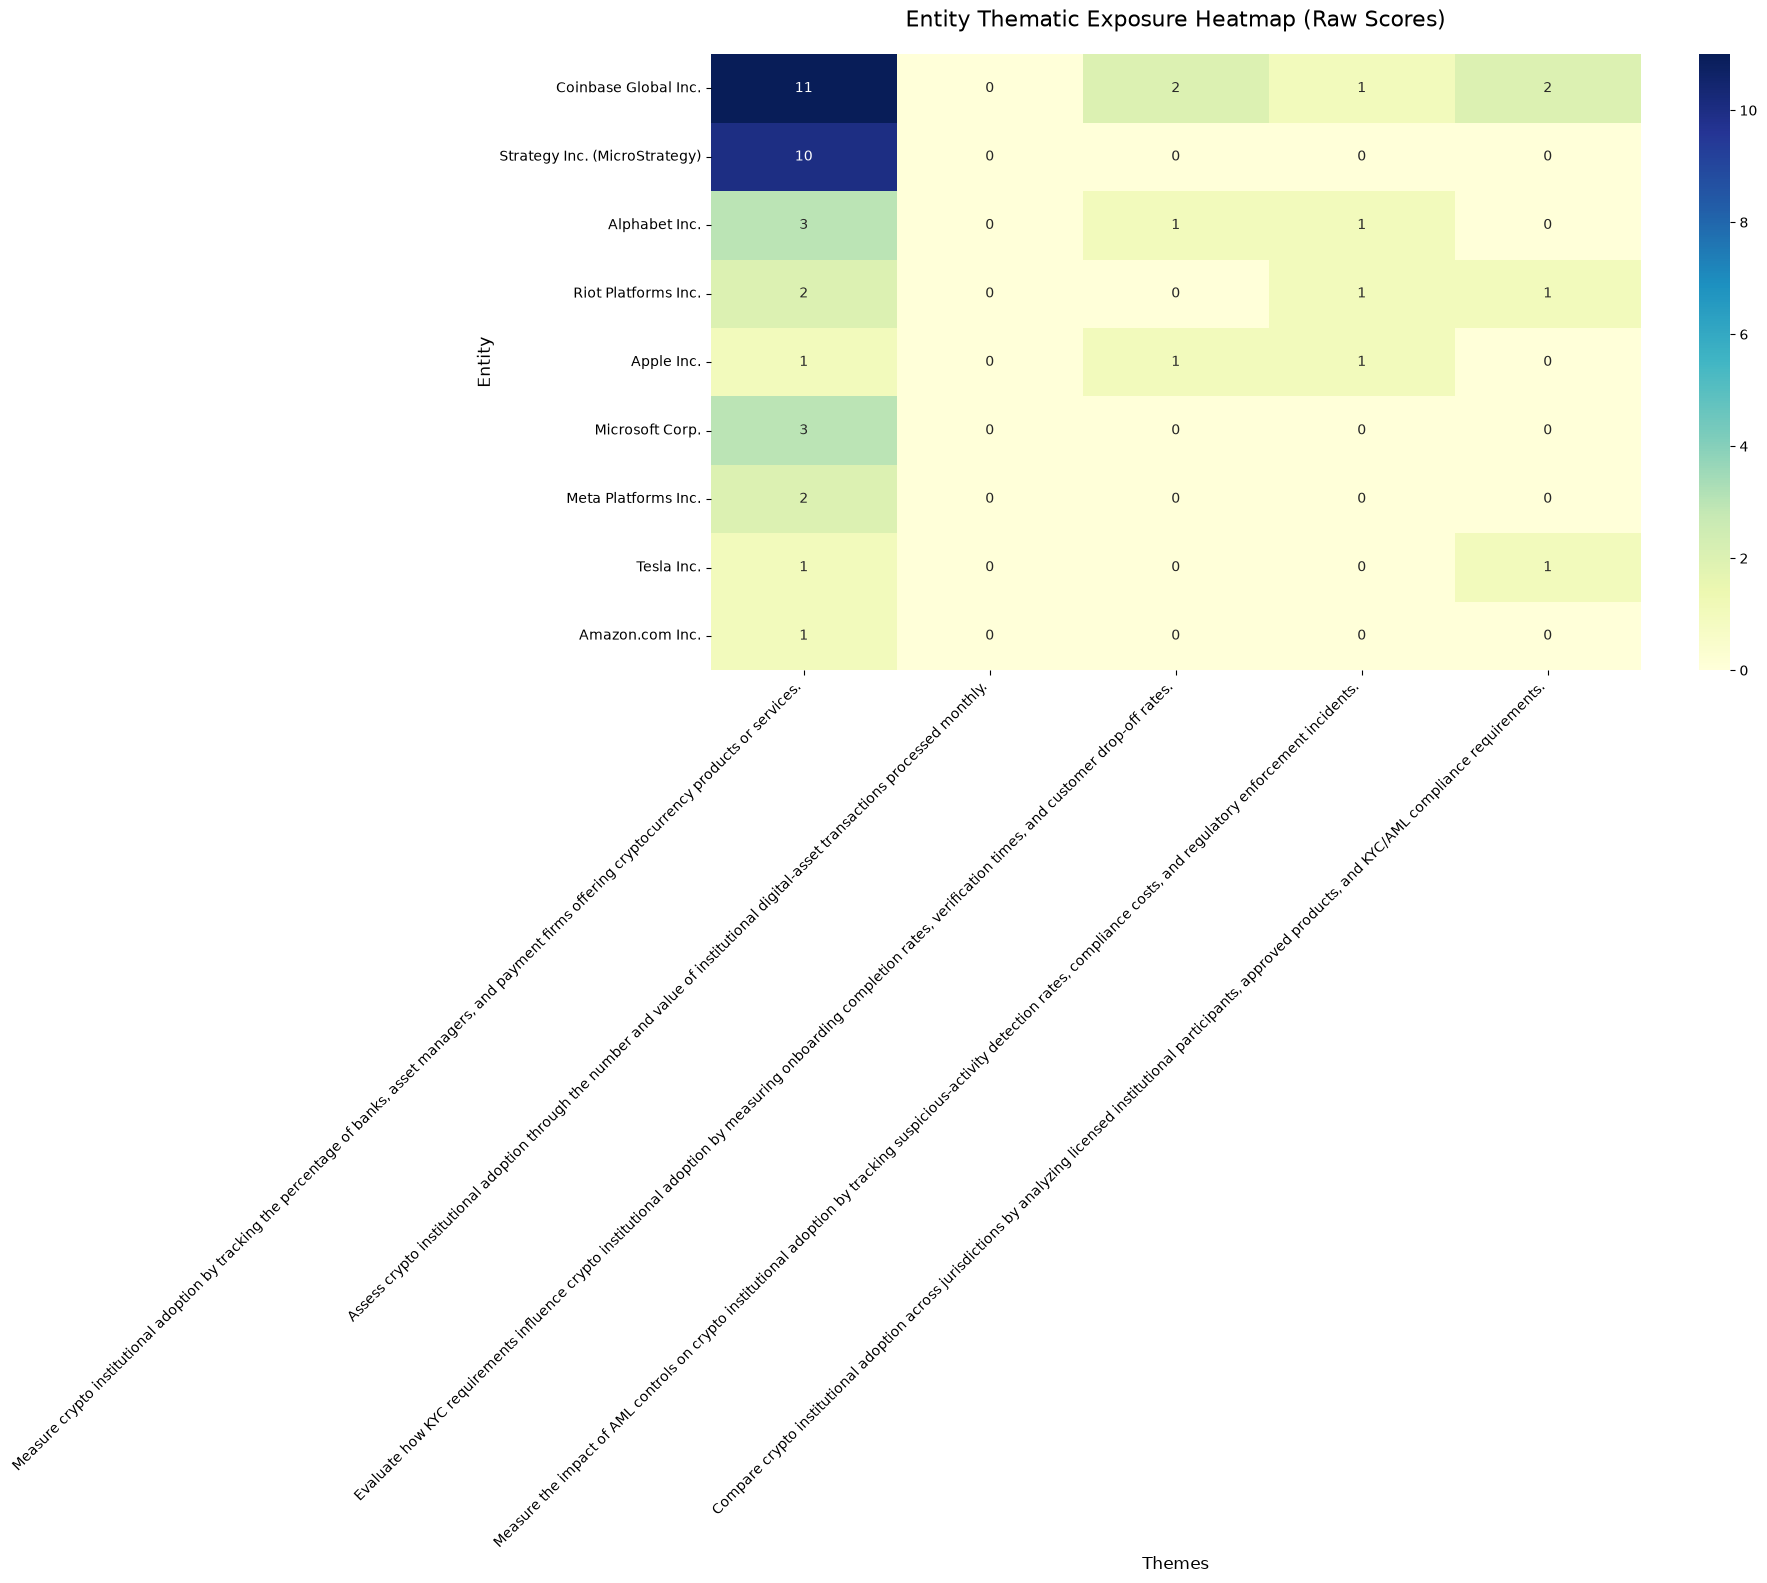

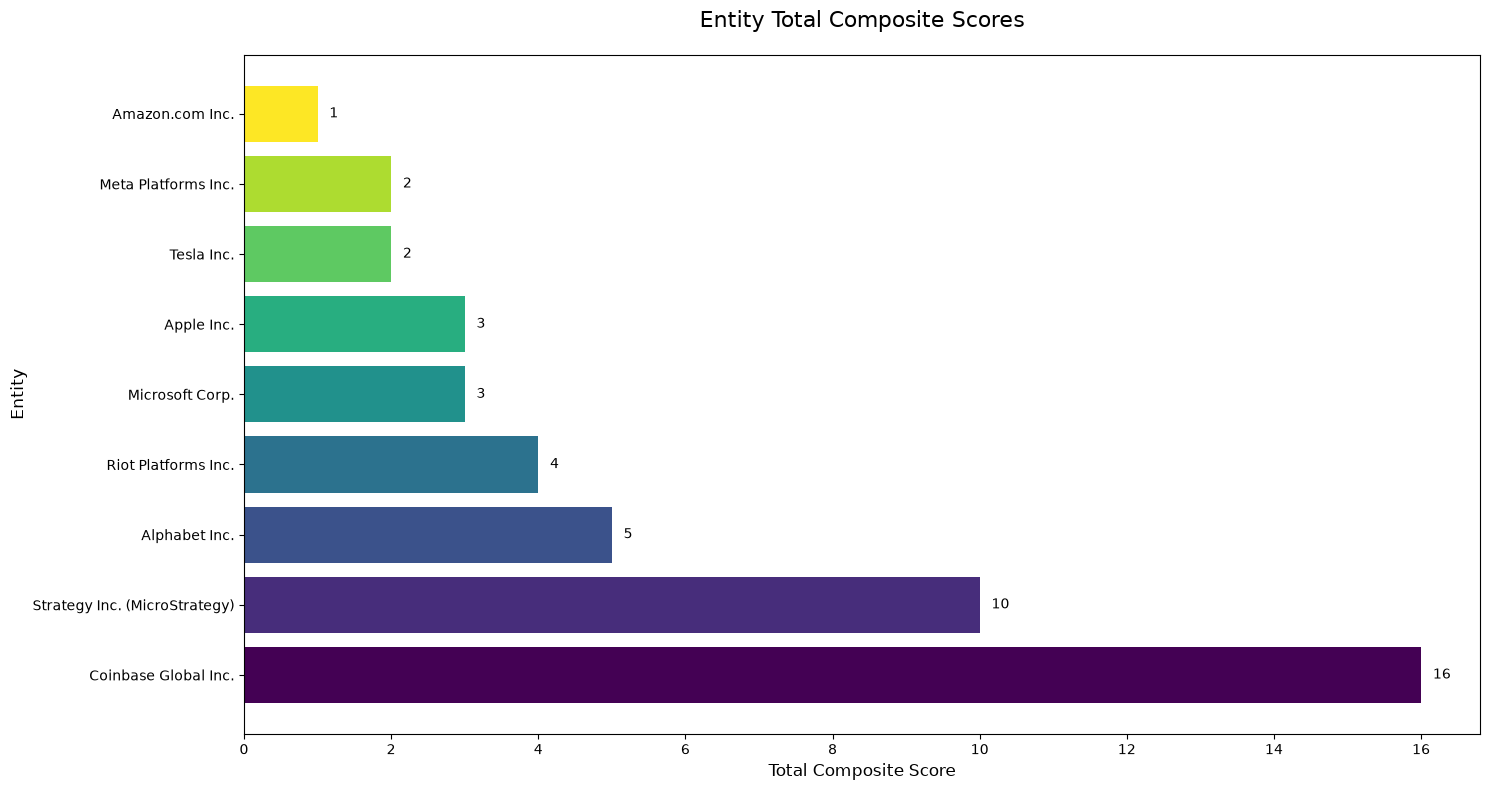

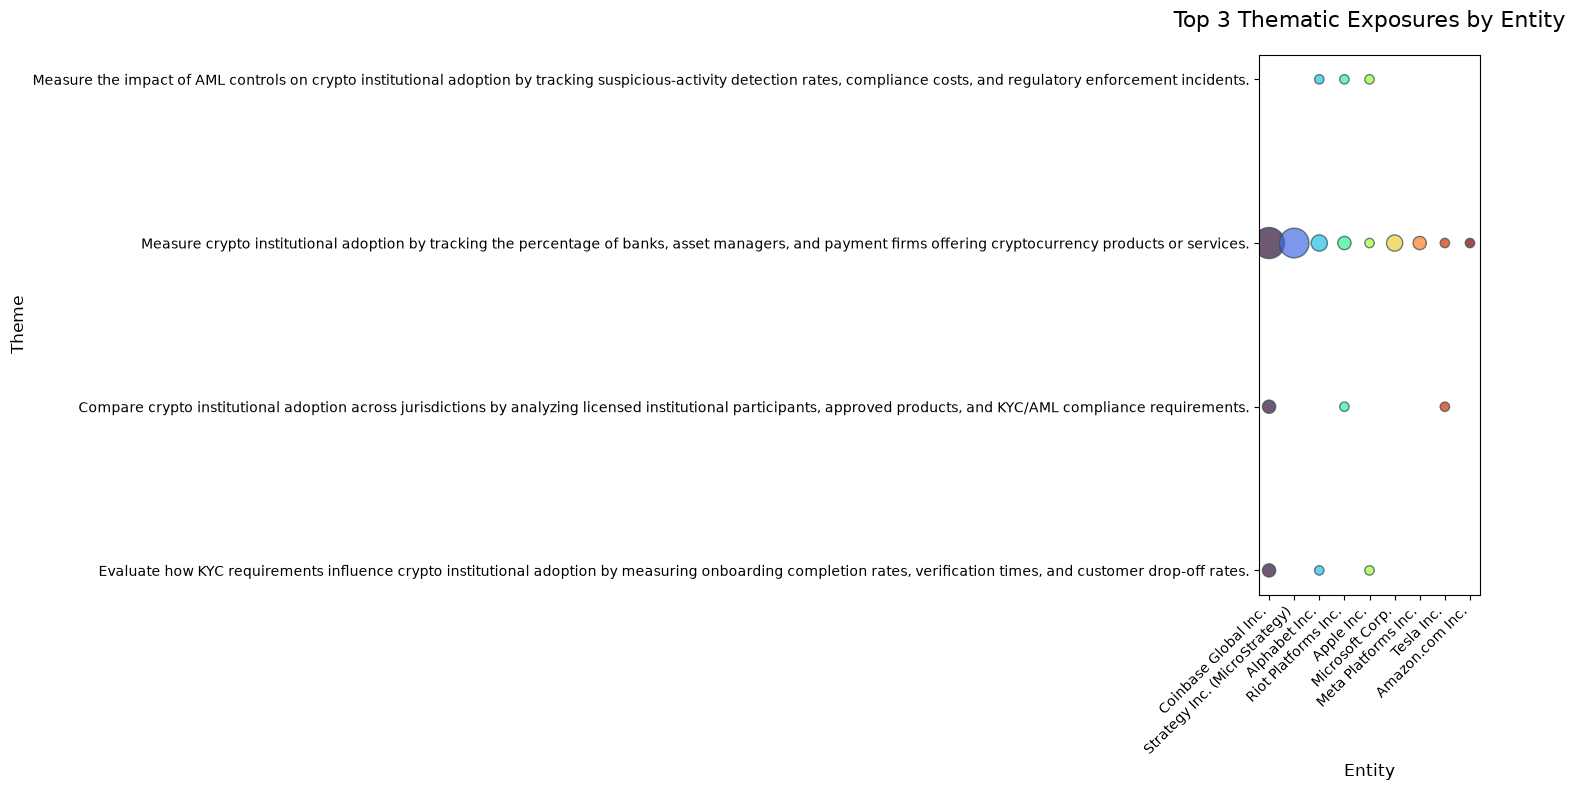

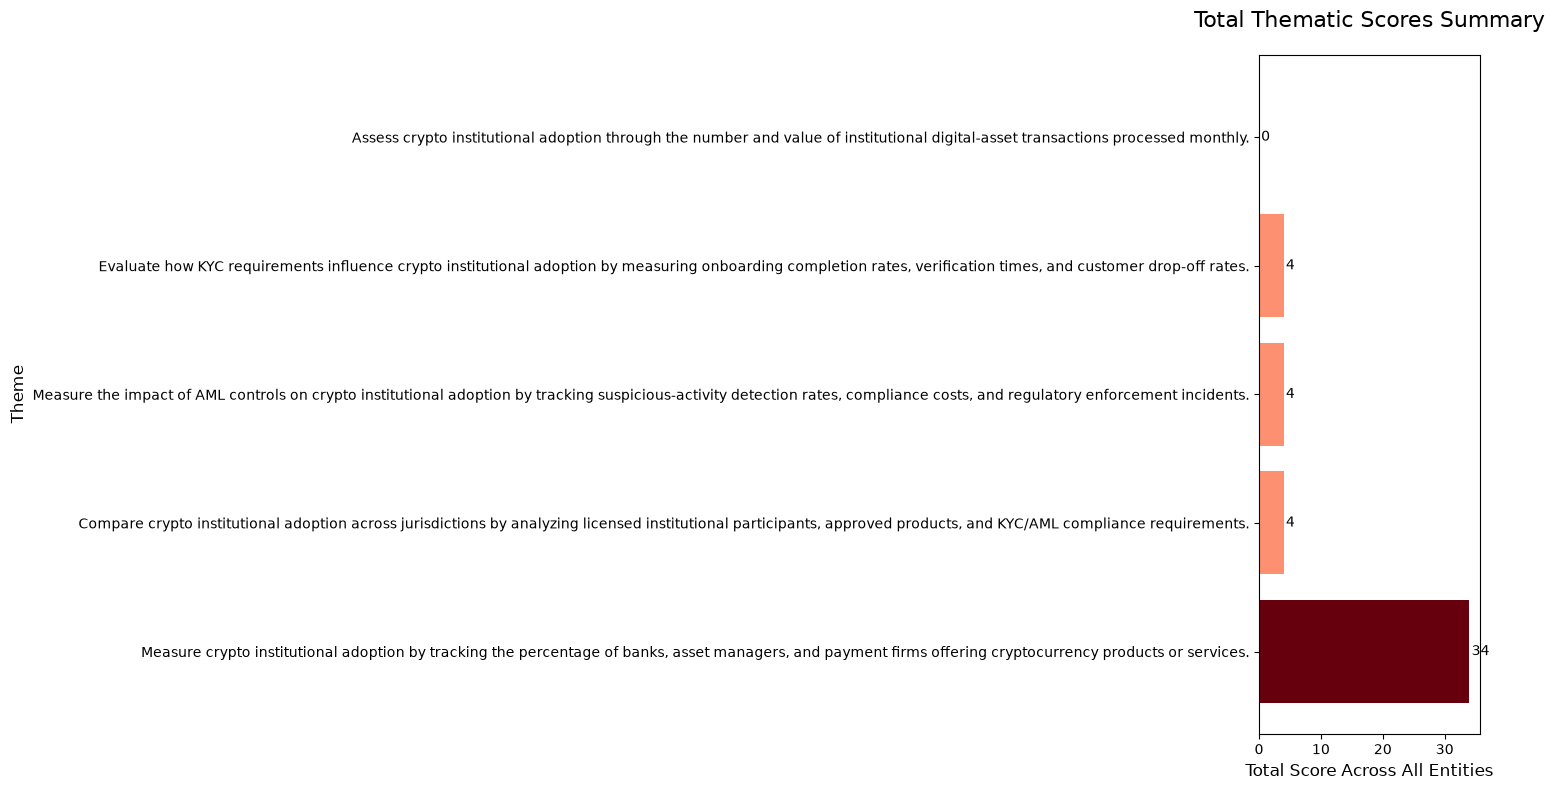

In [18]:
if df_entity.empty:
    print("No labeled thematic data to visualize for this narrow date window/sample.")
else:
    display_figures(df_entity, interactive=False, n_entities=10)
